In [ ]:


import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/lung-cancer-segmentation-lung-rads/lung_segmentation/lung_cancer_train.pkl
/kaggle/input/lung-cancer-segmentation-lung-rads/lung_segmentation/lung_cancer_test.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

In [ ]:
DATASET_PATH = '/kaggle/input/lung-cancer-segmentation-lung-rads'

In [ ]:
train_pkl = '/kaggle/input/lung-cancer-segmentation-lung-rads/lung_segmentation/lung_cancer_train.pkl'
test_pkl  = '/kaggle/input/lung-cancer-segmentation-lung-rads/lung_segmentation/lung_cancer_test.pkl'

train_data = pd.read_pickle(train_pkl)
test_data  = pd.read_pickle(test_pkl)

In [ ]:
print(type(train_data))
print(len(train_data))

<class 'pandas.core.frame.DataFrame'>
708


In [ ]:
print(train_data.head())
print(train_data.columns)

  label1                                               mask  \
0    LR2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
1    LR2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
2    LR2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
3    LR2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
4    LR2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   

                                            hu_array  \
0  [[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...   
1  [[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...   
2  [[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...   
3  [[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...   
4  [[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...   

                                        hu_array_old  
0  [[-1024.0, -1024.0, -1024.0, -1024.0, -1024.0,...  
1  [[-1024.0, -1024.0, -1024.0, -1024.0, -1024.0,...  
2  [[-1024.0, -1024.0, -1024.0, -1024.0, -1024.0,...  
3  [[-1024.0, -1024.0, -1024.0, -1024.0, -1024.0,...  
4  [[-102

### Meaning this is a pandas dataframe stored using pandas as pkl files

In [ ]:
sample = train_data.iloc[0]

print("label1:", sample["label1"])
print("mask shape:", sample["mask"].shape)
print("hu_array shape:", sample["hu_array"].shape)

label1: LR2
mask shape: (512, 512)
hu_array shape: (512, 512)


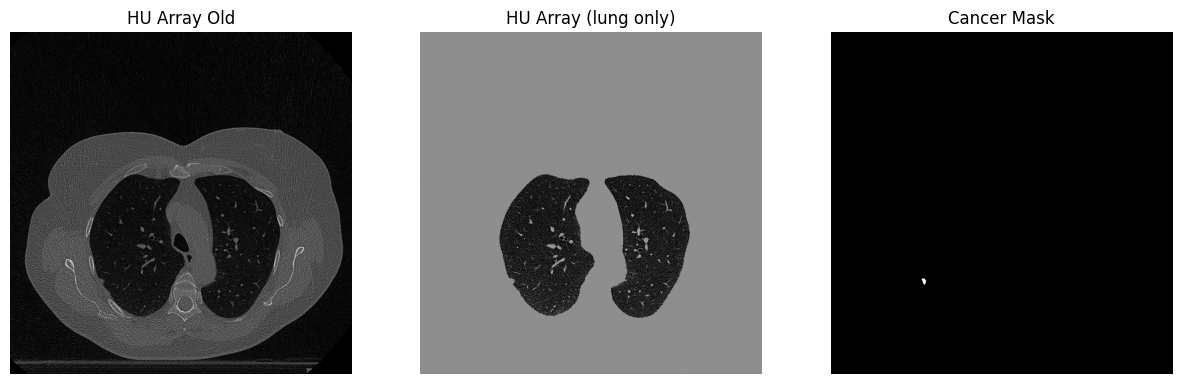

In [ ]:
sample = train_data.iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample["hu_array_old"], cmap="gray")
axes[0].set_title("HU Array Old")
axes[0].axis("off")

axes[1].imshow(sample["hu_array"], cmap="gray")
axes[1].set_title("HU Array (lung only)")
axes[1].axis("off")

axes[2].imshow(sample["mask"], cmap="gray")
axes[2].set_title("Cancer Mask")
axes[2].axis("off")

plt.savefig("/kaggle/working/lung_sample_visualization.pdf",
            bbox_inches="tight")

plt.show()

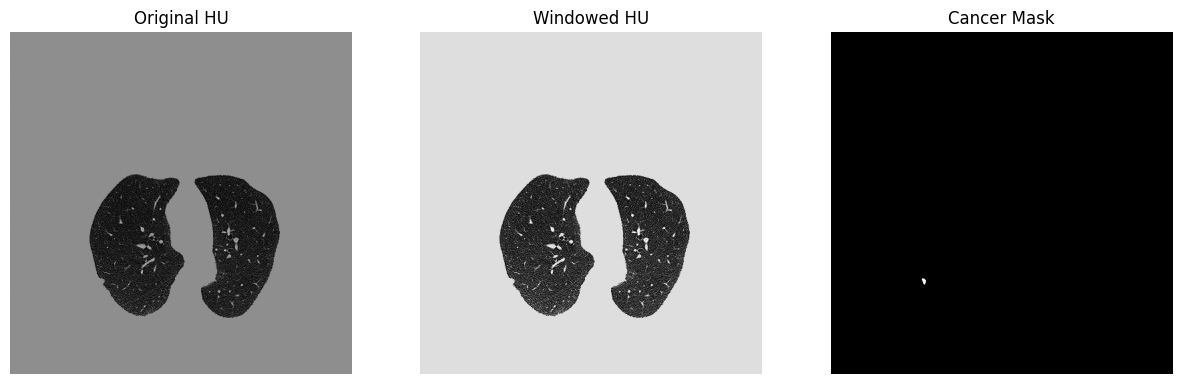

In [ ]:
# pick ONE sample
sample_window = train_data.iloc[0]

hu = np.array(sample_window["hu_array"])        # lung-only CT
mask = np.array(sample_window["mask"])          # cancer mask



# Windowing function

def window_hu(hu, center=-600, width=1500):

    low = center - width / 2
    high = center + width / 2

    hu = np.clip(hu, low, high)
    hu = (hu - low) / (high - low)
    hu = (hu * 255).astype(np.uint8)

    return hu


# Apply windowing
img = window_hu(hu)



# Convert to 3-channel, yolo requirment
img_rgb = np.stack([img, img, img], axis=-1)


#plots
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(hu, cmap="gray")
plt.title("Original HU")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img, cmap="gray")
plt.title("Windowed HU")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask, cmap="gray")
plt.title("Cancer Mask")
plt.axis("off")
plt.savefig("/kaggle/working/lung_sample_window.pdf",
            bbox_inches="tight")
plt.show()

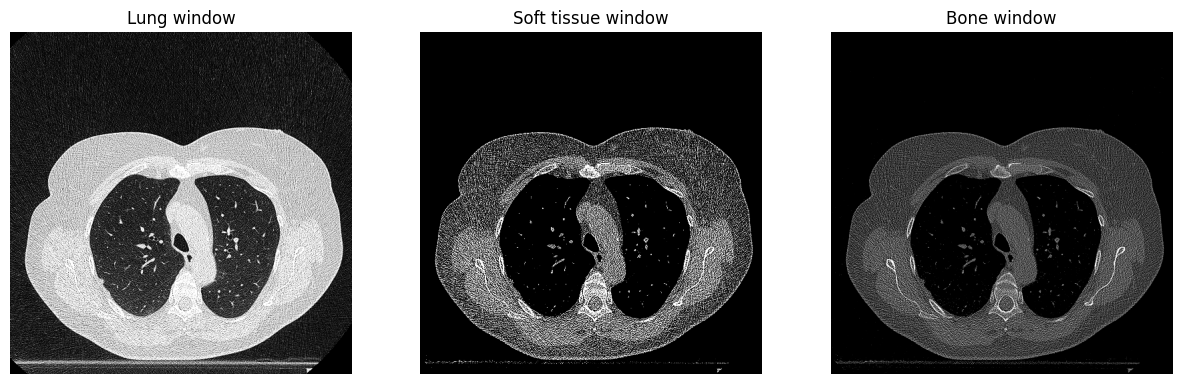

In [ ]:
sample_window2 = train_data.iloc[0]
hu2 = np.array(sample_window2["hu_array_old"])        # lung-only CT
mask = np.array(sample_window2["mask"])          # cancer mask
def window_hu(hu2, center, width):
    low = center - width / 2
    high = center + width / 2
    hu2 = np.clip(hu2, low, high)
    hu2 = (hu2 - low) / (high - low)
    return (hu2 * 255).astype(np.uint8)

lung = window_hu(hu2, -600, 1500)
soft = window_hu(hu2, 50, 400)
bone = window_hu(hu2, 300, 1500)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(lung, cmap="gray")
plt.title("Lung window")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(soft, cmap="gray")
plt.title("Soft tissue window")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(bone, cmap="gray")
plt.title("Bone window")
plt.axis("off")
plt.savefig("/kaggle/working/lung_sample_windows.pdf",
            bbox_inches="tight")
plt.show()

In [ ]:
sample = train_data.iloc[0]

hu_array_old = sample["hu_array_old"]   # full CT slice (HU)
hu_array     = sample["hu_array"]       # lung-only CT slice (HU)
mask         = sample["mask"]           # cancer mask (0/1)

In [ ]:
def window_hu(hu_array, center=-600, width=1500):
    low = center - width / 2
    high = center + width / 2

    hu_clipped = np.clip(hu_array, low, high)
    hu_normalized = (hu_clipped - low) / (high - low)

    return (hu_normalized * 255).astype(np.uint8)

In [ ]:
lung_window_img = window_hu(hu_array_old, center=-600, width=1500)

In [ ]:
lung_mask = (hu_array != 0).astype(np.uint8)

lung_only_img = lung_window_img * lung_mask

In [ ]:
lung  = window_hu(hu_array_old, -600, 1500)
soft  = window_hu(hu_array_old, 50, 400)
bone  = window_hu(hu_array_old, 300, 1500)

multi_channel_img = np.stack([lung, soft, bone], axis=-1)

In [ ]:
target_mask = mask.astype(np.uint8)

In [ ]:
print(np.unique(target_mask))  # should be [0 1]

[0 1]


In [ ]:
IMG_SIZE = 640

img_resized = cv2.resize(multi_channel_img, (IMG_SIZE, IMG_SIZE))
mask_resized = cv2.resize(
    target_mask,
    (IMG_SIZE, IMG_SIZE),
    interpolation=cv2.INTER_NEAREST
)

img_resized = img_resized.astype(np.float32) / 255.0

In [ ]:
def mask_to_yolo_polygons(mask):
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    h, w = mask.shape
    polygons = []

    for cnt in contours:
        if len(cnt) < 3:
            continue

        cnt = cnt.squeeze()
        poly = []
        for x, y in cnt:
            poly.append(x / w)
            poly.append(y / h)

        polygons.append(poly)

    return polygons


In [ ]:
polygons = mask_to_yolo_polygons(mask_resized)

In [ ]:
yolo_lines = []
CLASS_ID = 0  # lung cancer

for poly in polygons:
    line = str(CLASS_ID) + " " + " ".join(map(str, poly))
    yolo_lines.append(line)

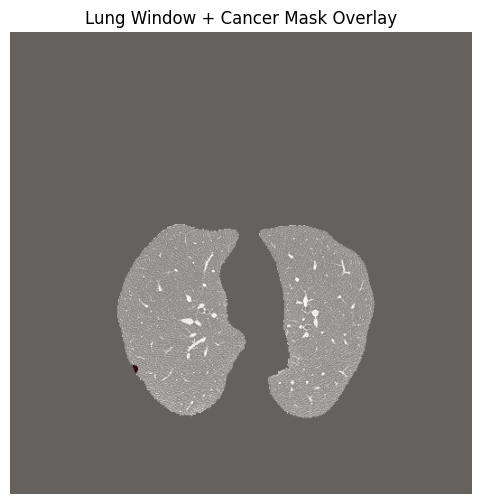

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(lung_only_img, cmap="gray")
plt.imshow(mask, alpha=0.4, cmap="Reds")
plt.title("Lung Window + Cancer Mask Overlay")
plt.axis("off")
plt.savefig("/kaggle/working/lung_win_mask.pdf",
            bbox_inches="tight")
plt.show()

In [ ]:
from tqdm import tqdm

In [ ]:
DATASET_DIR = "/kaggle/input/lung-cancer-segmentation-lung-rads/lung_segmentation"
OUTPUT_DIR  = "/kaggle/working/yolo_lung_seg"

IMG_SIZE = 640
CLASS_ID = 0  # lung cancer

In [ ]:
os.makedirs(f"{OUTPUT_DIR}/images/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/images/val", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels/val", exist_ok=True)

In [ ]:
train_df = pd.read_pickle(f"{DATASET_DIR}/lung_cancer_train.pkl")
val_df   = pd.read_pickle(f"{DATASET_DIR}/lung_cancer_test.pkl")

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 708
Val: 264


In [ ]:
def window_hu(hu, center, width):
    low = center - width / 2
    high = center + width / 2
    hu = np.clip(hu, low, high)
    hu = (hu - low) / (high - low)
    return (hu * 255).astype(np.uint8)

In [ ]:
def mask_to_yolo_polygons(mask):
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    h, w = mask.shape
    polygons = []

    for cnt in contours:
        if len(cnt) < 3:
            continue

        cnt = cnt.squeeze()
        poly = []
        for x, y in cnt:
            poly.append(x / w)
            poly.append(y / h)

        polygons.append(poly)

    return polygons

In [ ]:
def process_split(df, split="train"):
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        hu_old = row["hu_array_old"]
        hu_lung = row["hu_array"]
        mask = row["mask"].astype(np.uint8)

        # Windowing to lung mask to multi mask to resize and normalize
        lung  = window_hu(hu_old, -600, 1500)
        soft  = window_hu(hu_old, 50, 400)
        bone  = window_hu(hu_old, 300, 1500)

        lung_mask = (hu_lung != 0).astype(np.uint8)
        lung = lung * lung_mask
        img = np.stack([lung, soft, bone], axis=-1)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask_resized = cv2.resize(
            mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST
        )

        img_path = f"{OUTPUT_DIR}/images/{split}/{idx}.png"
        cv2.imwrite(img_path, img)

        # mask to polygons
        polygons = mask_to_yolo_polygons(mask_resized)

        label_path = f"{OUTPUT_DIR}/labels/{split}/{idx}.txt"
        with open(label_path, "w") as f:
            for poly in polygons:
                line = str(CLASS_ID) + " " + " ".join(map(str, poly))
                f.write(line + "\n")


In [ ]:
process_split(train_df, split="train")
process_split(val_df, split="val")

100%|██████████| 264/264 [00:06<00:00, 40.79it/s]


In [ ]:

import yaml
data_yaml = {
    "path": OUTPUT_DIR,
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "lung_cancer"
    }
}

with open(f"{OUTPUT_DIR}/data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working/yolo_lung_seg",
    "zip",
    "/kaggle/working/yolo_lung_seg"
)


'/kaggle/working/yolo_lung_seg.zip'